<a href="https://colab.research.google.com/github/tipismaca/Trabajo-Bebidas-del-Maipo-SA/blob/main/CasodeEstudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf Trabajo-Bebidas-del-Maipo-SA #lo que hace esta linea es que elimina la clonacion anterior (la con coma)
!git clone https://github.com/tipismaca/Trabajo-Bebidas-del-Maipo-SA.git

Cloning into 'Trabajo-Bebidas-del-Maipo-SA'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 158 (delta 12), reused 0 (delta 0), pack-reused 134 (from 1)
Receiving objects: 100% (158/158), 4.48 MiB | 11.68 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt

RESUMEN — FASE I: SEMANAS 1–6
Promedios, rangos y límites expresados en mL.


,Línea,Formato (L),Promedio,Rango medio,LCI X̄,LCS X̄,LCI R,LCS R
0,L1,0.5,503.04,4.85,500.24,505.84,0.0,10.25
1,L2,1.5,1504.74,11.89,1497.88,1511.60,0.0,25.14
2,L2,3.0,3008.68,20.07,2997.10,3020.26,0.0,42.44


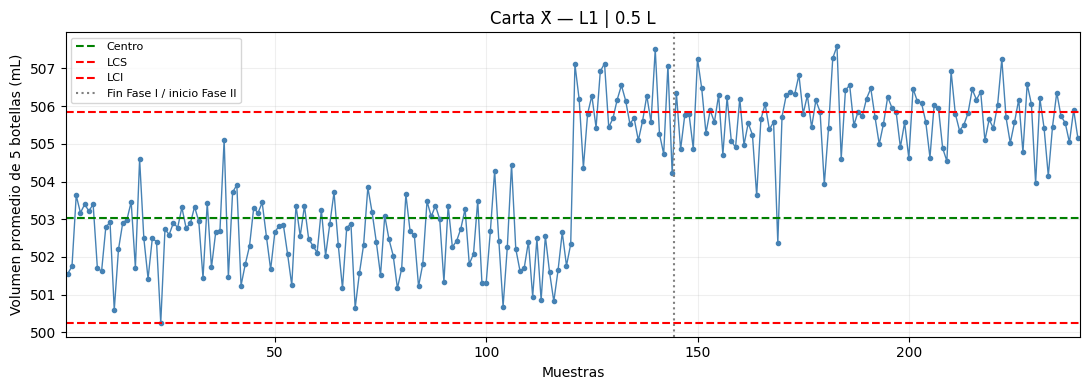

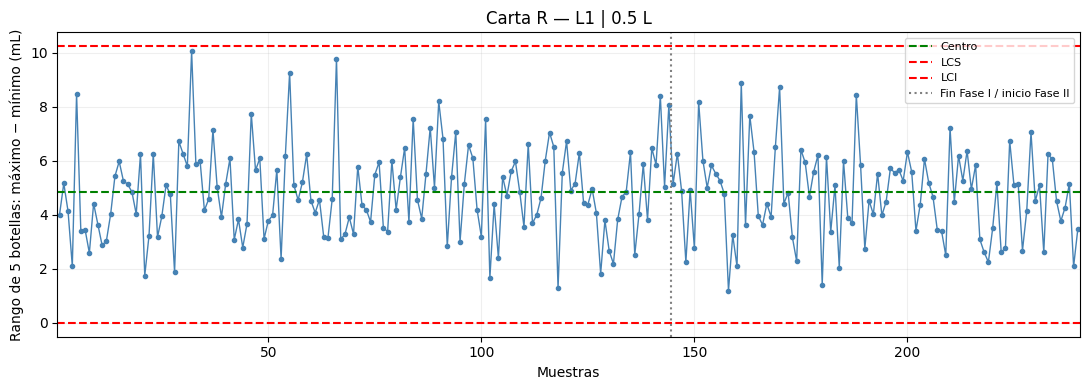

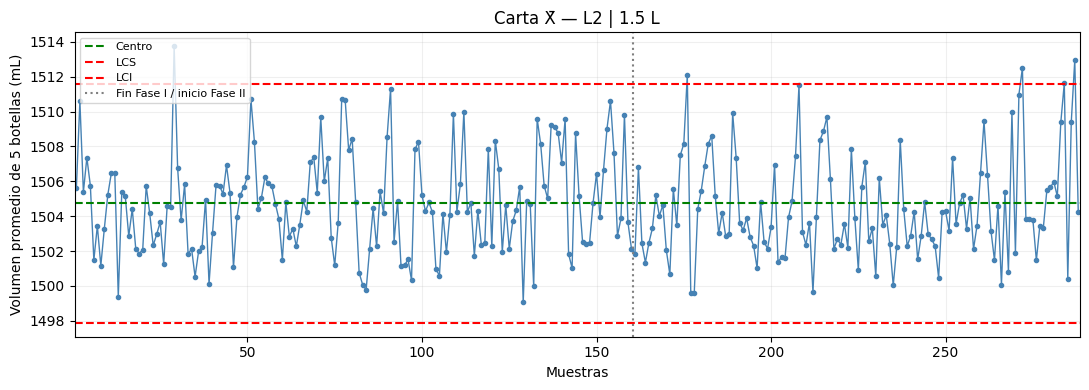

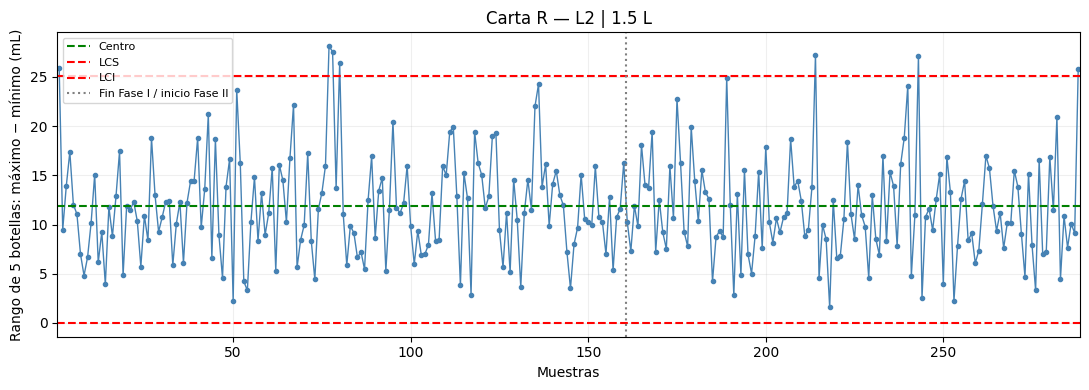

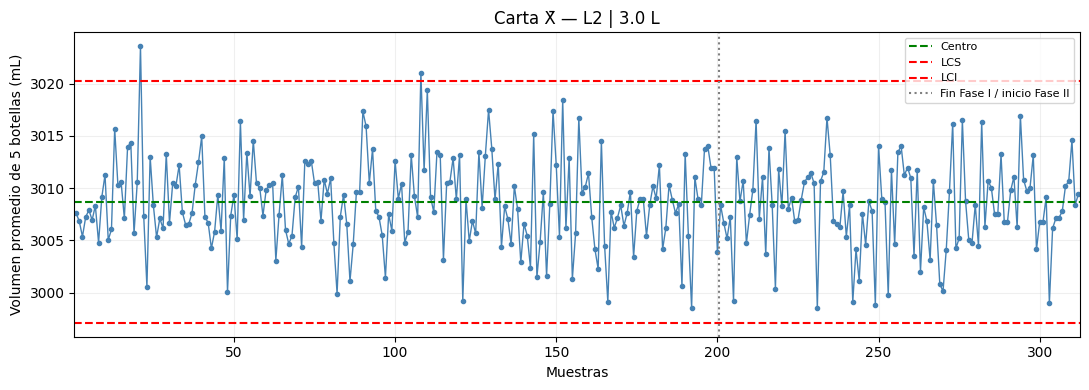

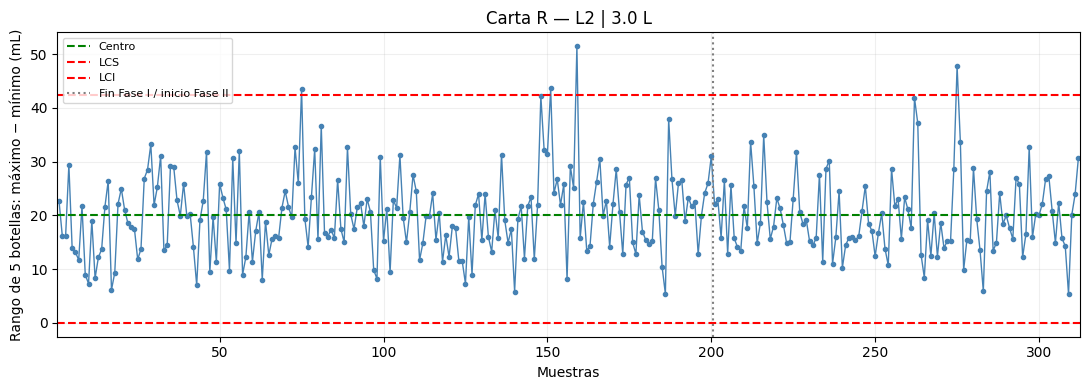

In [3]:
# PARTE A — PASO 1: CARTAS DE CONTROL DEL LLENADO

# 1. LEER LOS DATOS

ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

df_llenado = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especs = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')
df_atributos = pd.read_csv(ruta_base + 'calidad_atributos.csv')


# 2. CALCULAR PROMEDIO Y RANGO DE CADA SUBGRUPO

subgrupos = df_llenado.groupby(
    ['linea', 'formato_L', 'subgrupo']
).agg(
    X_bar=('volumen_mL', 'mean'),
    R=('volumen_mL', lambda x: x.max() - x.min()),
    semana=('semana_registro', 'first'),
    turno=('turno', 'first'),
    sku=('sku', 'first')
).reset_index()


# 3. CALCULAR LOS LÍMITES CON LA FASE I

# Elegimos X̄-R porque cada subgrupo tiene 5 botellas.
A2, D3, D4, d2 = 0.577, 0.0, 2.114, 2.326

# Fase I: semanas 1–6. Fase II: semanas 7–10.
fase1 = subgrupos[subgrupos['semana'] <= 6]

limites_f1 = {}
resumen = []

for (linea, formato), g in fase1.groupby(['linea', 'formato_L']):

    X_db = g['X_bar'].mean()
    R_b = g['R'].mean()

    UCL_X = X_db + A2 * R_b
    LCL_X = X_db - A2 * R_b

    UCL_R = D4 * R_b
    LCL_R = D3 * R_b

    limites_f1[(linea, formato)] = {
        'X_db': X_db,
        'R_b': R_b,
        'UCL_X': UCL_X,
        'LCL_X': LCL_X,
        'UCL_R': UCL_R,
        'LCL_R': LCL_R,
        'sigma_corto': R_b / d2
    }

    resumen.append({
        'Línea': linea,
        'Formato (L)': formato,
        'Promedio': X_db,
        'Rango medio': R_b,
        'LCI X̄': LCL_X,
        'LCS X̄': UCL_X,
        'LCI R': LCL_R,
        'LCS R': UCL_R
    })

print('RESUMEN — FASE I: SEMANAS 1–6')
print('Promedios, rangos y límites expresados en mL.')

tabla_limites = pd.DataFrame(resumen)
display(tabla_limites.round(2))


# 4. GRAFICAR POR LÍNEA Y FORMATO

for (linea, formato), datos in subgrupos.groupby(['linea', 'formato_L']):

    datos = datos.sort_values('subgrupo')
    lim = limites_f1[(linea, formato)]

    muestras = np.arange(1, len(datos) + 1)
    cantidad_fase1 = len(datos[datos['semana'] <= 6])
    corte = cantidad_fase1 + 0.5

    # CARTA X̄

    plt.figure(figsize=(11, 4))

    plt.plot(
        muestras, datos['X_bar'],
        'o-', color='steelblue', markersize=3, linewidth=1
    )

    plt.axhline(lim['X_db'], color='green', linestyle='--', label='Centro')
    plt.axhline(lim['UCL_X'], color='red', linestyle='--', label='LCS')
    plt.axhline(lim['LCL_X'], color='red', linestyle='--', label='LCI')

    plt.axvline(
        corte, color='gray', linestyle=':',
        label='Fin Fase I / inicio Fase II'
    )

    plt.title(f'Carta X̄ — {linea} | {formato} L')
    plt.xlabel('Muestras')
    plt.ylabel('Volumen promedio de 5 botellas (mL)')
    plt.xlim(0.5, len(datos) + 0.5)
    plt.legend(fontsize=8, loc='best')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # CARTA R

    plt.figure(figsize=(11, 4))

    plt.plot(
        muestras, datos['R'],
        'o-', color='steelblue', markersize=3, linewidth=1
    )

    plt.axhline(lim['R_b'], color='green', linestyle='--', label='Centro')
    plt.axhline(lim['UCL_R'], color='red', linestyle='--', label='LCS')
    plt.axhline(lim['LCL_R'], color='red', linestyle='--', label='LCI')

    plt.axvline(
        corte, color='gray', linestyle=':',
        label='Fin Fase I / inicio Fase II'
    )

    plt.title(f'Carta R — {linea} | {formato} L')
    plt.xlabel('Muestras')
    plt.ylabel('Rango de 5 botellas: máximo − mínimo (mL)')
    plt.xlim(0.5, len(datos) + 0.5)
    plt.legend(fontsize=8, loc='best')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [4]:
# PARTE A — PASO 2: SEÑALES Y POSIBLES CAUSAS

# 1. DEFINIR LAS REGLAS Y LAS HIPÓTESIS A INVESTIGAR

reglas = ['N1', 'N2', 'N3', 'N5', 'R_fuera']

causas_posibles = {
    'N1': 'Ajuste puntual incorrecto o perturbación del llenado',
    'N2': 'Cambio sostenido del ajuste o calibración',
    'N3': 'Deriva gradual por temperatura, presión o desgaste',
    'N5': 'Desplazamiento del ajuste de llenado',
    'R_fuera': 'Irregularidad de boquillas o presión de llenado'
}

tablas = []
senales = []


# 2. DETECTAR LAS SEÑALES POR LÍNEA Y FORMATO

for (linea, formato), datos in subgrupos.groupby(['linea', 'formato_L']):

    datos = datos.sort_values('subgrupo').copy()
    lim = limites_f1[(linea, formato)]

    promedio = datos['X_bar']
    centro = lim['X_db']
    sigma_X = (lim['UCL_X'] - centro) / 3

    # N1: un promedio fuera de los límites
    datos['N1'] = (
        (promedio > lim['UCL_X']) |
        (promedio < lim['LCL_X'])
    )

    # N2: nueve promedios seguidos al mismo lado del centro
    datos['N2'] = (
        ((promedio > centro).rolling(9).sum() == 9) |
        ((promedio < centro).rolling(9).sum() == 9)
    )

    # N3: seis promedios seguidos aumentando o disminuyendo
    cambio = promedio.diff()

    datos['N3'] = (
        ((cambio > 0).rolling(5).sum() == 5) |
        ((cambio < 0).rolling(5).sum() == 5)
    )

    # N5: dos de tres promedios más allá de dos sigmas,
    # del mismo lado del centro
    datos['N5'] = (
        ((promedio > centro + 2 * sigma_X).rolling(3).sum() >= 2) |
        ((promedio < centro - 2 * sigma_X).rolling(3).sum() >= 2)
    )

    # Carta R: rango fuera de los límites
    datos['R_fuera'] = (
        (datos['R'] > lim['UCL_R']) |
        (datos['R'] < lim['LCL_R'])
    )

    datos['fase'] = np.where(
        datos['semana'] <= 6, 'Fase I', 'Fase II'
    )

    datos['alerta'] = datos[reglas].any(axis=1)
    tablas.append(datos)

    # Guardar cada señal con su contexto y una hipótesis
    for indice, fila in datos.iterrows():

        for regla in reglas:

            if fila[regla]:
                senales.append({
                    'Línea': linea,
                    'Formato (L)': formato,
                    'Subgrupo': fila['subgrupo'],
                    'Fase': fila['fase'],
                    'Semana': fila['semana'],
                    'Turno': fila['turno'],
                    'SKU': fila['sku'],
                    'Regla': regla,
                    'Causa posible': causas_posibles[regla]
                })


# 3. REUNIR LOS RESULTADOS

df_control = pd.concat(tablas, ignore_index=True)

# El detalle completo queda guardado, sin mostrarlo entero.
df_senales = pd.DataFrame(senales)


# 4. MOSTRAR EL RESUMEN POR REGLA Y FASE

resumen_reglas = df_control.groupby(
    ['linea', 'formato_L', 'fase']
)[reglas].sum().reset_index()

resumen_reglas = resumen_reglas.rename(columns={
    'linea': 'Línea',
    'formato_L': 'Formato (L)',
    'fase': 'Fase',
    'R_fuera': 'R fuera de límites'
})

print('ACTIVACIONES POR REGLA Y FASE')

display(
    resumen_reglas.style
    .hide(axis='index')
    .format({'Formato (L)': '{:.1f}'})
)


# 5. MOSTRAR LAS HIPÓTESIS UTILIZADAS

tabla_causas = pd.DataFrame({
    'Señal': reglas,
    'Causa posible a investigar': [
        causas_posibles[regla] for regla in reglas
    ]
})

print('HIPÓTESIS: NO SON CAUSAS CONFIRMADAS')
display(tabla_causas.style.hide(axis='index'))


# 6. CONTRASTAR POR SEMANA, TURNO Y SKU

for campo in ['semana', 'turno', 'sku']:

    comparacion = df_control.groupby(
        ['linea', 'formato_L', campo]
    ).agg(
        muestras=('subgrupo', 'count'),
        con_alerta=('alerta', 'sum')
    ).reset_index()

    comparacion['porcentaje'] = (
        100 * comparacion['con_alerta']
        / comparacion['muestras']
    )

    comparacion = comparacion.rename(columns={
        'linea': 'Línea',
        'formato_L': 'Formato (L)',
        campo: campo.upper(),
        'muestras': 'Muestras observadas',
        'con_alerta': 'Muestras con señal',
        'porcentaje': '% con señal'
    })

    print(f'CONTRASTE POR {campo.upper()}')

    display(
        comparacion.style
        .hide(axis='index')
        .format({
            'Formato (L)': '{:.1f}',
            '% con señal': '{:.2f}'
        })
    )

ACTIVACIONES POR REGLA Y FASE


Línea,Formato (L),Fase,N1,N2,N3,N5,R fuera de límites
L1,0.5,Fase I,11,23,0,23,0
L1,0.5,Fase II,42,87,0,93,0
L2,1.5,Fase I,1,1,2,4,4
L2,1.5,Fase II,4,0,2,10,3
L2,3.0,Fase I,2,0,1,1,3
L2,3.0,Fase II,0,0,4,2,1


HIPÓTESIS: NO SON CAUSAS CONFIRMADAS


Señal,Causa posible a investigar
N1,Ajuste puntual incorrecto o perturbación del llenado
N2,Cambio sostenido del ajuste o calibración
N3,"Deriva gradual por temperatura, presión o desgaste"
N5,Desplazamiento del ajuste de llenado
R_fuera,Irregularidad de boquillas o presión de llenado


CONTRASTE POR SEMANA


Línea,Formato (L),SEMANA,Muestras observadas,Muestras con señal,% con señal
L1,0.5,1,24,0,0.00
L1,0.5,2,24,1,4.17
L1,0.5,3,24,0,0.00
L1,0.5,4,24,0,0.00
L1,0.5,5,24,7,29.17
L1,0.5,6,24,24,100.00
L1,0.5,7,24,24,100.00
L1,0.5,8,24,24,100.00
L1,0.5,9,24,24,100.00
L1,0.5,10,24,24,100.00


CONTRASTE POR TURNO


Línea,Formato (L),TURNO,Muestras observadas,Muestras con señal,% con señal
L1,0.5,A (06-14),120,64,53.33
L1,0.5,B (14-22),120,64,53.33
L2,1.5,A (06-14),108,6,5.56
L2,1.5,B (14-22),76,1,1.32
L2,1.5,C (22-06),104,19,18.27
L2,3.0,A (06-14),92,5,5.43
L2,3.0,B (14-22),124,2,1.61
L2,3.0,C (22-06),96,7,7.29


CONTRASTE POR SKU


Línea,Formato (L),SKU,Muestras observadas,Muestras con señal,% con señal
L1,0.5,CIT-L05,96,47,48.96
L1,0.5,FUN-B05,64,32,50.00
L1,0.5,NEC-D05,80,49,61.25
L2,1.5,CIT-L15,88,5,5.68
L2,1.5,FUN-B15,104,12,11.54
L2,1.5,NEC-D15,96,9,9.38
L2,3.0,CIT-L30,136,7,5.15
L2,3.0,FUN-B30,80,4,5.00
L2,3.0,NEC-D30,96,3,3.12


In [5]:
# PARTE A — PASO 3: CAPACIDAD Y LÍMITE LEGAL

# 1. LEER LAS ESPECIFICACIONES

df_especs = pd.read_csv(
    ruta_base + 'especificaciones_calidad.csv'
)

print('ESPECIFICACIONES DEL LLENADO — mL')
print(df_especs.to_string(index=False))


# 2. CALCULAR LOS ÍNDICES GLOBALMENTE Y POR TURNO

resultados_capacidad = []
resultados_legal = []

for (linea, formato), datos in df_llenado.groupby(
    ['linea', 'formato_L']
):

    espec = df_especs[df_especs['formato_L'] == formato].iloc[0]

    LIE = espec['LIE_mL']
    LSE = espec['LSE_mL']
    limite_legal = espec['limite_legal_inferior_mL']

    grupos = [('Global', datos)]

    for turno, datos_turno in datos.groupby('turno'):
        grupos.append((turno, datos_turno))

    for nombre, grupo in grupos:

        # Cp y Cpk: semanas 1–6
        datos_fase1 = grupo[grupo['semana_registro'] <= 6]

        rangos = datos_fase1.groupby('subgrupo')['volumen_mL'].agg(
            lambda x: x.max() - x.min()
        )

        sigma_corto = rangos.mean() / d2
        media_fase1 = datos_fase1['volumen_mL'].mean()

        Cp = (LSE - LIE) / (6 * sigma_corto)

        Cpk = min(
            (LSE - media_fase1) / (3 * sigma_corto),
            (media_fase1 - LIE) / (3 * sigma_corto)
        )

        # Pp y Ppk: todas las semanas
        media_total = grupo['volumen_mL'].mean()
        s_total = grupo['volumen_mL'].std()

        Pp = (LSE - LIE) / (6 * s_total)

        Ppk = min(
            (LSE - media_total) / (3 * s_total),
            (media_total - LIE) / (3 * s_total)
        )

        resultados_capacidad.append([
            linea, formato, nombre,
            media_fase1, media_total,
            Cp, Cpk, Pp, Ppk
        ])

        # Contar botellas bajo el límite legal inferior
        n_botellas = len(grupo)

        bajo_legal = (
            grupo['volumen_mL'] < limite_legal
        ).sum()

        porcentaje = 100 * bajo_legal / n_botellas

        resultados_legal.append([
            linea, formato, nombre, limite_legal,
            n_botellas, bajo_legal, porcentaje
        ])


# 3. ORGANIZAR LOS RESULTADOS EN TABLAS

columnas_capacidad = [
    'Linea', 'Formato_L', 'Grupo',
    'Media_FaseI_mL', 'Media_total_mL',
    'Cp', 'Cpk', 'Pp', 'Ppk'
]

df_capacidad = pd.DataFrame(
    resultados_capacidad,
    columns=columnas_capacidad
)

columnas_legal = [
    'Linea', 'Formato_L', 'Grupo',
    'Limite_legal_mL', 'Botellas_medidas',
    'Bajo_limite', 'Porcentaje_bajo'
]

df_legal = pd.DataFrame(
    resultados_legal,
    columns=columnas_legal
)

capacidad_global = df_capacidad[
    df_capacidad['Grupo'] == 'Global'
]

capacidad_turnos = df_capacidad[
    df_capacidad['Grupo'] != 'Global'
]


# 4. MOSTRAR LOS RESULTADOS

print('\nCAPACIDAD GLOBAL')
print('Cp/Cpk: Fase I. Pp/Ppk: todo el período.')
print(capacidad_global.round(3).to_string(index=False))

print('\nCAPACIDAD POR TURNO')
print(capacidad_turnos.round(3).to_string(index=False))

print('\nREVISIÓN DEL LÍMITE LEGAL INFERIOR')
print(df_legal.round(2).to_string(index=False))

ESPECIFICACIONES DEL LLENADO — mL
 formato_L  nominal_mL  LIE_mL  LSE_mL  tolerancia_oiml_mL  limite_legal_inferior_mL
       0.5       500.0   492.0   508.0                15.0                     485.0
       1.5      1500.0  1485.0  1515.0                22.5                    1477.5
       3.0      3000.0  2975.0  3025.0                45.0                    2955.0

CAPACIDAD GLOBAL
Cp/Cpk: Fase I. Pp/Ppk: todo el período.
Linea  Formato_L  Grupo  Media_FaseI_mL  Media_total_mL    Cp   Cpk    Pp   Ppk
   L1        0.5 Global         503.040         504.094 1.280 0.793 1.023 0.500
   L2        1.5 Global        1504.739        1504.601 0.978 0.669 0.922 0.639
   L2        3.0 Global        3008.680        3008.501 0.966 0.630 0.946 0.624

CAPACIDAD POR TURNO
Linea  Formato_L     Grupo  Media_FaseI_mL  Media_total_mL    Cp   Cpk    Pp   Ppk
   L1        0.5 A (06-14)         502.984         504.023 1.306 0.819 1.016 0.505
   L1        0.5 B (14-22)         503.096         504.164 1

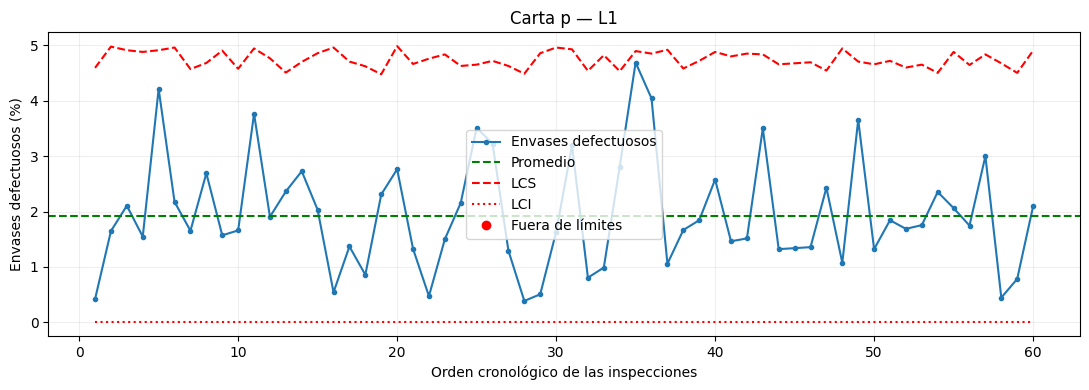


INSPECCIONES FUERA DE LÍMITES — L1
No hay puntos fuera de los límites.


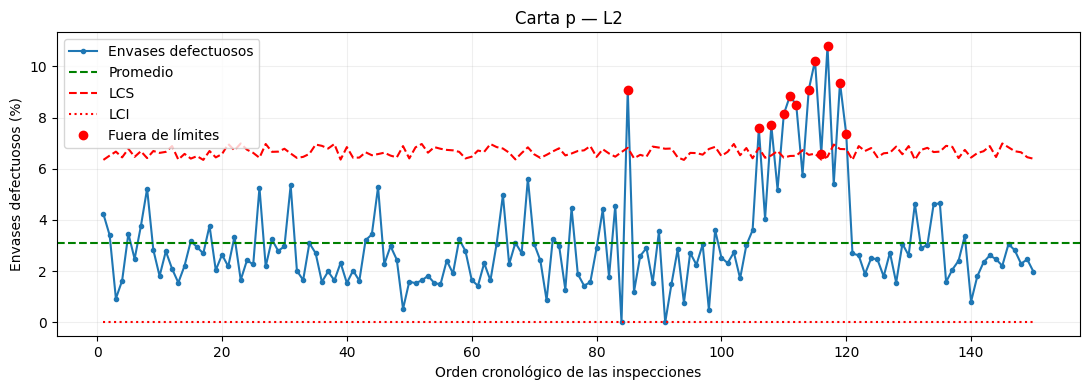


INSPECCIONES FUERA DE LÍMITES — L2
     fecha  semana_registro     turno     sku  n_inspeccionadas  n_defectuosas  causa_principal
2026-08-27                6 A (06-14) FUN-B30               198             18 Nivel de llenado
2026-09-07                8 A (06-14) CIT-L30               198             15         Etiqueta
2026-09-07                8 C (22-06) NEC-D30               234             18         Etiqueta
2026-09-08                8 B (14-22) FUN-B15               246             20         Etiqueta
2026-09-08                8 C (22-06) FUN-B15               237             21         Etiqueta
2026-09-09                8 A (06-14) CIT-L30               236             20       Sello/tapa
2026-09-09                8 C (22-06) CIT-L30               231             21         Etiqueta
2026-09-10                8 A (06-14) NEC-D30               225             23 Nivel de llenado
2026-09-10                8 B (14-22) CIT-L30               258             17         Etiqueta
2026

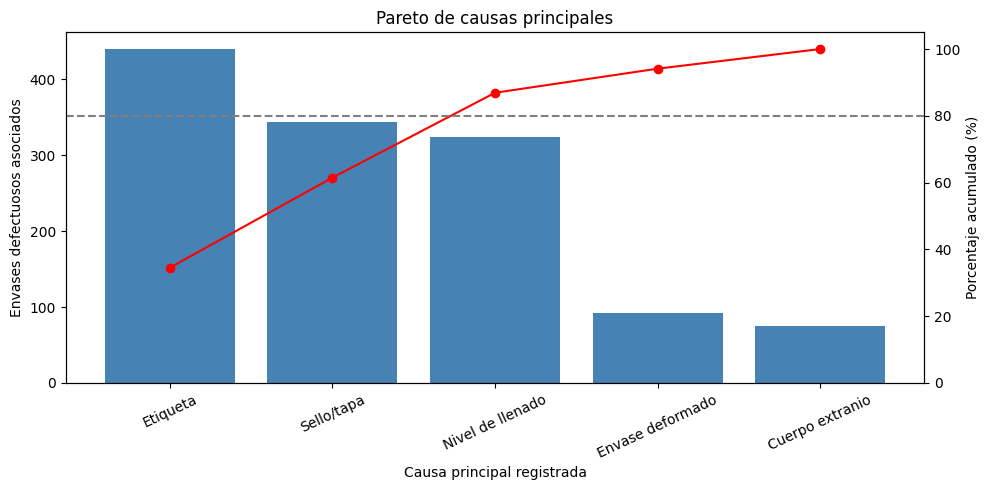

In [6]:
# PARTE A — PASO 4: CARTA p Y PARETO

# 1. LEER LOS DATOS DE INSPECCIÓN

df_at = pd.read_csv(
    ruta_base + 'calidad_atributos.csv'
)

resumen = []


# 2. CALCULAR Y GRAFICAR LA CARTA p POR LÍNEA

for linea, datos in df_at.groupby('linea'):

    datos = datos.sort_values(['fecha', 'turno']).copy()

    total_insp = datos['n_inspeccionadas'].sum()
    total_def = datos['n_defectuosas'].sum()

    p_bar = total_def / total_insp

    datos['p'] = (
        datos['n_defectuosas'] / datos['n_inspeccionadas']
    )

    error = np.sqrt(
        p_bar * (1 - p_bar) / datos['n_inspeccionadas']
    )

    datos['LCI'] = (p_bar - 3 * error).clip(lower=0)
    datos['LCS'] = (p_bar + 3 * error).clip(upper=1)

    datos['fuera'] = (
        (datos['p'] < datos['LCI']) |
        (datos['p'] > datos['LCS'])
    )

    datos['orden'] = np.arange(1, len(datos) + 1)

    resumen.append([
        linea,
        total_insp,
        total_def,
        100 * p_bar,
        datos['fuera'].sum()
    ])

    # Gráfico
    plt.figure(figsize=(11, 4))

    plt.plot(
        datos['orden'], 100 * datos['p'],
        'o-', markersize=3, label='Envases defectuosos'
    )

    plt.axhline(
        100 * p_bar,
        color='green', linestyle='--', label='Promedio'
    )

    plt.plot(
        datos['orden'], 100 * datos['LCS'],
        color='red', linestyle='--', label='LCS'
    )

    plt.plot(
        datos['orden'], 100 * datos['LCI'],
        color='red', linestyle=':', label='LCI'
    )

    fuera = datos[datos['fuera']]

    plt.plot(
        fuera['orden'], 100 * fuera['p'],
        'ro', label='Fuera de límites'
    )

    plt.title('Carta p — ' + linea)
    plt.xlabel('Orden cronológico de las inspecciones')
    plt.ylabel('Envases defectuosos (%)')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Mostrar los registros fuera de límites
    print('\nINSPECCIONES FUERA DE LÍMITES — ' + linea)

    columnas = [
        'fecha', 'semana_registro', 'turno', 'sku',
        'n_inspeccionadas', 'n_defectuosas', 'causa_principal'
    ]

    if len(fuera) == 0:
        print('No hay puntos fuera de los límites.')
    else:
        print(fuera[columnas].to_string(index=False))


# 3. MOSTRAR EL RESUMEN POR LÍNEA

tabla_atributos = pd.DataFrame(
    resumen,
    columns=[
        'Linea',
        'Inspeccionadas',
        'Defectuosas',
        'Porcentaje_defectuosas',
        'Puntos_fuera'
    ]
)

print('\nRESUMEN POR LÍNEA')
print(tabla_atributos.round(2).to_string(index=False))


# 4. ORGANIZAR LAS CAUSAS PARA EL PARETO

con_defectos = df_at[df_at['n_defectuosas'] > 0]

pareto = con_defectos.groupby(
    'causa_principal'
)['n_defectuosas'].sum()

pareto = pareto.sort_values(ascending=False).reset_index()

pareto.columns = ['Causa_principal', 'Defectuosas_asociadas']

pareto['Porcentaje'] = (
    100 * pareto['Defectuosas_asociadas']
    / pareto['Defectuosas_asociadas'].sum()
)

pareto['Acumulado'] = pareto['Porcentaje'].cumsum()

print('\nPARETO POR CAUSA PRINCIPAL')
print(pareto.round(2).to_string(index=False))


# 5. GRAFICAR EL PARETO

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    pareto['Causa_principal'],
    pareto['Defectuosas_asociadas'],
    color='steelblue'
)

ax1.set_xlabel('Causa principal registrada')
ax1.set_ylabel('Envases defectuosos asociados')
ax1.tick_params(axis='x', labelrotation=25)

ax2 = ax1.twinx()

ax2.plot(
    pareto['Causa_principal'],
    pareto['Acumulado'],
    color='red', marker='o'
)

ax2.set_ylabel('Porcentaje acumulado (%)')
ax2.set_ylim(0, 105)
ax2.axhline(80, color='gray', linestyle='--')

plt.title('Pareto de causas principales')
plt.tight_layout()
plt.show()

In [7]:
# PARTE A — PASO 5: SOBRELLENADO Y COSTO ANUAL ESTIMADO

# 1. LEER LOS ARCHIVOS

df_maestro = pd.read_csv(ruta_base + 'maestro_sku.csv')
df_ventas = pd.read_csv(ruta_base + 'demanda_semanal.csv')


# 2. CALCULAR EL SOBRELLENADO MEDIO POR FORMATO

resultados_llenado = []

for (linea, formato), datos in df_llenado.groupby(
    ['linea', 'formato_L']
):

    espec = df_especs[df_especs['formato_L'] == formato].iloc[0]

    nominal = espec['nominal_mL']
    promedio = datos['volumen_mL'].mean()

    exceso_mL = max(promedio - nominal, 0)

    resultados_llenado.append([
        linea, formato, nominal, promedio, exceso_mL
    ])

tabla_sobrellenado = pd.DataFrame(
    resultados_llenado,
    columns=[
        'Linea', 'Formato_L', 'Nominal_mL',
        'Promedio_mL', 'Exceso_mL_botella'
    ]
)

print('SOBRELLENADO MEDIO — TODAS LAS SEMANAS DE LLENADO')
print(tabla_sobrellenado.round(2).to_string(index=False))


# 3. SELECCIONAR LAS ÚLTIMAS 52 SEMANAS DE VENTAS

ultima_semana = df_ventas['semana'].max()

ventas_anuales = df_ventas[
    df_ventas['semana'] > ultima_semana - 52
]


# 4. ESTIMAR LOS LITROS ADICIONALES Y SU COSTO POR SKU

resultados_costos = []

for indice, producto in df_maestro.iterrows():

    sku = producto['sku']
    formato = producto['formato_L']

    llenado = tabla_sobrellenado[
        tabla_sobrellenado['Formato_L'] == formato
    ].iloc[0]

    exceso_mL = llenado['Exceso_mL_botella']
    botellas_caja = producto['botellas_por_caja']

    # Convertir el exceso por botella a litros por caja
    exceso_L_caja = exceso_mL * botellas_caja / 1000

    ventas_sku = ventas_anuales[
        ventas_anuales['sku'] == sku
    ]

    cajas_anuales = ventas_sku['ventas_cajas'].sum()

    litros_extra = exceso_L_caja * cajas_anuales

    # Aproximación del costo variable por litro
    costo_L = (
        producto['costo_variable_caja_clp']
        / producto['litros_por_caja']
    )

    costo_anual = litros_extra * costo_L

    resultados_costos.append([
        sku,
        formato,
        botellas_caja,
        exceso_L_caja,
        cajas_anuales,
        litros_extra,
        costo_L,
        costo_anual
    ])

tabla_costos = pd.DataFrame(
    resultados_costos,
    columns=[
        'SKU',
        'Formato_L',
        'Botellas_caja',
        'Exceso_L_caja',
        'Cajas_anuales_ref',
        'Litros_extra_estimados',
        'Costo_CLP_L',
        'Costo_anual_estimado_CLP'
    ]
)


# 5. MOSTRAR RESULTADOS Y TOTALES

print('\nESTIMACIÓN ANUAL POR SKU')
print(tabla_costos.round(3).to_string(index=False))

total_litros = tabla_costos['Litros_extra_estimados'].sum()
total_costo = tabla_costos['Costo_anual_estimado_CLP'].sum()

print('\nTOTAL ANUAL ESTIMADO')
print('Litros adicionales:', round(total_litros, 2))
print('Costo variable aproximado en CLP:', round(total_costo))

print('\nSupuestos: ventas como aproximación de producción anual')
print('y costo variable proporcional a los litros.')
print('Actualizar la estimación después de limpiar las ventas en B.1.')

SOBRELLENADO MEDIO — TODAS LAS SEMANAS DE LLENADO
Linea  Formato_L  Nominal_mL  Promedio_mL  Exceso_mL_botella
   L1        0.5       500.0       504.09               4.09
   L2        1.5      1500.0      1504.60               4.60
   L2        3.0      3000.0      3008.50               8.50

ESTIMACIÓN ANUAL POR SKU
    SKU  Formato_L  Botellas_caja  Exceso_L_caja  Cajas_anuales_ref  Litros_extra_estimados  Costo_CLP_L  Costo_anual_estimado_CLP
NEC-D05        0.5             12          0.049            79233.0                3892.171        640.0               2490989.173
NEC-D15        1.5              6          0.028           139996.0                3864.782        640.0               2473460.528
NEC-D30        3.0              4          0.034            32359.0                1100.356        640.0                704227.955
CIT-L05        0.5             12          0.049           133114.0                6538.972        470.0               3073316.997
CIT-L15        1.5       

In [14]:
# 1. Definir la ruta base de la carpeta clonada
ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

# 2. Leer los archivos CSV sin modificar los datos crudos originales
df_calidad = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especificaciones = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')

# 3. Agrupar por línea y formato como exige la Parte A
# Se calcula la media y el rango (máximo - mínimo) para cada subgrupo (n=5)
resumen_subgrupos = df_calidad.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    media_volumen=('volumen_mL', 'mean'),
    rango_volumen=('volumen_mL', lambda x: np.ptp(x)) # np.ptp (peak-to-peak) calcula max - min
).reset_index()

# Mostrar las primeras filas para verificar que cargó y calculó bien
display(resumen_subgrupos.head())
display(df_especificaciones)

,linea,formato_L,subgrupo,media_volumen,rango_volumen
0,L1,0.5,1,501.560,4.01
1,L1,0.5,2,501.752,5.17
2,L1,0.5,3,503.630,4.13
3,L1,0.5,4,503.172,2.10
4,L1,0.5,5,503.396,8.49


,formato_L,nominal_mL,LIE_mL,LSE_mL,tolerancia_oiml_mL,limite_legal_inferior_mL
0,0.5,500.0,492.0,508.0,15.0,485.0
1,1.5,1500.0,1485.0,1515.0,22.5,1477.5
2,3.0,3000.0,2975.0,3025.0,45.0,2955.0


In [19]:
# 1. CARGAR LOS DATOS DESDE LA RUTA LOCAL CLONADA
# En lugar de usar un enlace de GitHub, usamos la ruta local ya disponible
ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'
df_demanda = pd.read_csv(ruta_base + 'demanda_semanal.csv', parse_dates=['fecha_lunes'])

# 2. CALCULAR LA DEMANDA RECONSTRUIDA
df_demanda['dias_con_stock'] = 7 - df_demanda['dias_sin_stock']
df_demanda['demanda_reconstruida'] = np.where(
    df_demanda['dias_con_stock'] > 0,
    (df_demanda['ventas_cajas'] / df_demanda['dias_con_stock']) * 7,
    np.nan
)

# Interpolamos y redondeamos
df_demanda['demanda_reconstruida'] = df_demanda.groupby('sku')['demanda_reconstruida'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)
df_demanda['demanda_reconstruida'] = df_demanda['demanda_reconstruida'].round()

print("¡Datos cargados localmente y demanda reconstruida con éxito!")

¡Datos cargados localmente y demanda reconstruida con éxito!


In [20]:
# PARTE B - PASO B.2: TRATAMIENTO DE LA CENSURA (VENTAS VS DEMANDA)

# 1. Calculamos cuántos días SÍ tuvimos stock para vender
df_demanda['dias_con_stock'] = 7 - df_demanda['dias_sin_stock']

# 2. Reconstrucción de la demanda real (Aplicación del supuesto matemático)
# Si tuvimos stock al menos 1 día, calculamos cuánto se vendía por día y lo multiplicamos por 7.
# Si estuvimos los 7 días sin stock, dejamos un vacío (np.nan) para rellenarlo después.
df_demanda['demanda_reconstruida'] = np.where(
    df_demanda['dias_con_stock'] > 0,
    (df_demanda['ventas_cajas'] / df_demanda['dias_con_stock']) * 7,
    np.nan
)

# 3. Interpolación (El plan B para quiebres totales)
# Para los huecos donde no hubo stock en toda la semana, estimamos la demanda
# promediando la semana anterior y la semana siguiente.
df_demanda['demanda_reconstruida'] = df_demanda.groupby('sku')['demanda_reconstruida'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# 4. Redondear (porque no existen fracciones de cajas)
df_demanda['demanda_reconstruida'] = df_demanda['demanda_reconstruida'].round()

print("--- DEMANDA RECONSTRUIDA CREADA CON ÉXITO ---")

--- DEMANDA RECONSTRUIDA CREADA CON ÉXITO ---


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.6 MB/s eta 0:00:00
Columnas disponibles en el archivo: ['semana', 'fecha_lunes', 'anio_iso', 'semana_iso', 'sku', 'ventas_cajas', 'dias_sin_stock', 'promocion', 'precio_lista_clp', 'precio_efectivo_clp', 'dias_con_stock', 'demanda_reconstruida']

--- ANÁLISIS DE CORRELACIÓN (JUSTIFICACIÓN DE REGRESORES) ---


,demanda_reconstruida,promocion
demanda_reconstruida,1.000000,0.206588
promocion,0.206588,1.000000


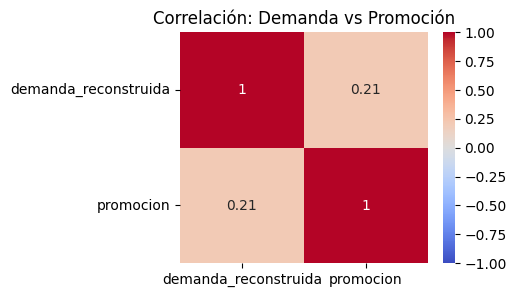


Datos de Entrenamiento (Historia) hasta: 2026-06-22
Datos de Prueba (Futuro a predecir): Últimas 13 semanas
--------------------------------------------------

Modelos cargados en memoria y listos para validación cruzada.


In [21]:

!pip install statsforecast

# PARTE B - PASO B.3: PARTICIÓN, JUSTIFICACIÓN DE REGRESORES Y MODELOS

import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive, ARIMA
import seaborn as sns
import matplotlib.pyplot as plt

# Imprimimos las columnas reales para confirmar qué datos nos entregó el profesor
print("Columnas disponibles en el archivo:", df_demanda.columns.tolist())

# --- 1. JUSTIFICACIÓN DE REGRESORES EXTERNOS (SOLO PROMOCIÓN) ---
print("\n--- ANÁLISIS DE CORRELACIÓN (JUSTIFICACIÓN DE REGRESORES) ---")
# Calculamos la correlación solo con la promoción
matriz_corr = df_demanda[['demanda_reconstruida', 'promocion']].corr()
display(matriz_corr)

# Gráfico de calor para el informe
plt.figure(figsize=(4, 3))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación: Demanda vs Promoción')
plt.show()

# --- 2. PREPARACIÓN DE DATOS (Formato StatsForecast) ---
# Incluimos solo 'promocion' como variable externa
df_sf = df_demanda[['sku', 'fecha_lunes', 'demanda_reconstruida', 'promocion']].copy()
df_sf = df_sf.rename(columns={'sku': 'unique_id', 'fecha_lunes': 'ds', 'demanda_reconstruida': 'y'})

# --- 3. PARTICIÓN TEMPORAL (Train / Test) ---
horizonte = 13
corte_fecha = df_sf['ds'].max() - pd.Timedelta(weeks=horizonte)

df_train = df_sf[df_sf['ds'] <= corte_fecha].copy()
df_test = df_sf[df_sf['ds'] > corte_fecha].copy()

print(f"\nDatos de Entrenamiento (Historia) hasta: {corte_fecha.date()}")
print(f"Datos de Prueba (Futuro a predecir): Últimas {horizonte} semanas")
print("-" * 50)

# --- 4. DEFINICIÓN DE LOS 3 MODELOS EXIGIDOS ---
temporada = 52 # Ciclo anual de 52 semanas

modelos_a_evaluar = [
    # 1. Benchmark Ingenuo (El piso mínimo exigido)
    SeasonalNaive(season_length=temporada),

    # 2. Modelo ETS (Suavización Exponencial)
    AutoETS(season_length=temporada),

    # 3. Modelo SARIMA Manual (SIN AutoARIMA)
    # Como le pasaremos la columna 'promocion', actuará como SARIMAX.
    ARIMA(order=(1, 1, 1), seasonal_order=(0, 1, 0), season_length=temporada)
]

# Instanciar StatsForecast
sf = StatsForecast(
    models=modelos_a_evaluar,
    freq='W-MON'
)

print("\nModelos cargados en memoria y listos para validación cruzada.")

In [ ]:
# PARTE B - PASO B.4: VALIDACIÓN CRUZADA DESAGREGADA POR HORIZONTE (h=1 al 13)

import matplotlib.pyplot as plt

# 1. Ejecutar la Validación Cruzada por Origen Deslizante
print("Ejecutando Validación Cruzada (8 ventanas, horizonte 13)... Puede tardar un poco.")
cv_results = sf.cross_validation(
    df=df_sf,
    h=horizonte,  # 13 semanas exigidas
    n_windows=8,  # 8 orígenes exigidos
    step_size=1   # Avanzamos 1 semana por ventana
)

# 2. Identificar el Horizonte 'h' (del 1 al 13) para cada ventana y producto
# Como los datos salen ordenados por fecha, los enumeramos del 1 al 13 por cada corte
cv_results['h'] = cv_results.groupby(['unique_id', 'cutoff']).cumcount() + 1

# 3. Reestructurar la tabla para calcular métricas por Modelo fácilmente
modelos_nombres = ['SeasonalNaive', 'AutoETS', 'ARIMA']
cv_melt = cv_results.melt(
    id_vars=['unique_id', 'ds', 'cutoff', 'y', 'h'],
    value_vars=modelos_nombres,
    var_name='Modelo',
    value_name='Prediccion'
)

# 4. Función para calcular las métricas exigidas
def calcular_metricas_por_h(df):
    suma_y = df['y'].sum()
    suma_abs_error = (df['y'] - df['Prediccion']).abs().sum()
    suma_error = (df['Prediccion'] - df['y']).sum()

    # Cálculos
    wape = suma_abs_error / suma_y if suma_y > 0 else np.nan
    sesgo = suma_error / suma_y if suma_y > 0 else np.nan
    mae = (df['y'] - df['Prediccion']).abs().mean()

    return pd.Series({'WAPE': wape, 'Sesgo': sesgo, 'MAE': mae})

# 5. Aplicar la función agrupando por Modelo y por Horizonte (h)
metricas_h = cv_melt.groupby(['Modelo', 'h']).apply(calcular_metricas_por_h).reset_index()

# 6. Calcular el MASE (Requiere comparar el MAE del modelo contra el MAE del Naive en ese mismo horizonte)
mae_naive = metricas_h[metricas_h['Modelo'] == 'SeasonalNaive'][['h', 'MAE']].rename(columns={'MAE': 'MAE_Naive'})
metricas_h = metricas_h.merge(mae_naive, on='h', how='left')
metricas_h['MASE'] = metricas_h['MAE'] / metricas_h['MAE_Naive']

# Limpiar las columnas finales
metricas_h = metricas_h[['Modelo', 'h', 'WAPE', 'MASE', 'Sesgo']]

# --- MOSTRAR RESULTADOS DESAGREGADOS ---
print("\n--- REPORTE DE ERRORES DESAGREGADOS POR HORIZONTE (Muestra de h=1 a h=13) ---")
# Hacemos una tabla pivote para que se vea elegante en tu informe
tabla_wape = metricas_h.pivot(index='h', columns='Modelo', values='WAPE')
display(tabla_wape.round(4))

# --- GRÁFICO PARA EL INFORME (EL PROFE LO AMARÁ) ---
plt.figure(figsize=(10, 5))
for modelo in modelos_nombres:
    df_plot = metricas_h[metricas_h['Modelo'] == modelo]
    # Destacamos el benchmark con línea punteada negra
    estilo = '--' if modelo == 'SeasonalNaive' else '-'
    grosor = 2 if modelo == 'SeasonalNaive' else 1.5
    plt.plot(df_plot['h'], df_plot['WAPE'], marker='o', linestyle=estilo, linewidth=grosor, label=modelo)

plt.title('Degradación del Pronóstico: Error (WAPE) vs Horizonte de Tiempo (h)')
plt.xlabel('Horizonte de Pronóstico (h semanas en el futuro)')
plt.ylabel('WAPE (Error Absoluto Porcentual)')
plt.xticks(range(1, 14))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ejecutando Validación Cruzada (8 ventanas, horizonte 13)... Puede tardar un poco.


In [ ]:
# 0. Instalar la librería de pronósticos jerárquicos
!pip install hierarchicalforecast
# PARTE B - PASO B.5: RECONCILIACIÓN JERÁRQUICA (BOTTOM-UP, TOP-DOWN, MIDDLE-OUT)

import pandas as pd
import numpy as np
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, TopDown, MiddleOut
from statsforecast import StatsForecast
from statsforecast.models import AutoETS

# --- 1. CONSTRUIR LA JERARQUÍA (Planta -> Familia -> SKU) ---
df_h = df_demanda[['sku', 'fecha_lunes', 'demanda_reconstruida']].copy()
df_h = df_h.rename(columns={'sku': 'sku', 'fecha_lunes': 'ds', 'demanda_reconstruida': 'y'})

df_h['planta'] = 'Planta_Maipo'
df_h['familia'] = df_h['sku'].str.split('-').str[0]

df_h = df_h[['planta', 'familia', 'sku', 'ds', 'y']]

especificacion = [
    ['planta'],
    ['planta', 'familia'],
    ['planta', 'familia', 'sku']
]

Y_df, S_df, tags = aggregate(df=df_h, spec=especificacion)

# --- 2. PARTICIÓN TEMPORAL JERÁRQUICA ---
horizonte = 13
corte_fecha = Y_df['ds'].max() - pd.Timedelta(weeks=horizonte)

Y_train = Y_df[Y_df['ds'] <= corte_fecha].copy()
Y_test = Y_df[Y_df['ds'] > corte_fecha].copy()

# --- 3. PRONÓSTICO BASE (AutoETS) ---
fcst = StatsForecast(models=[AutoETS(season_length=52)], freq='W-MON')

Y_hat_base = fcst.forecast(df=Y_train, h=horizonte, fitted=True)
Y_fitted = fcst.forecast_fitted_values()

# --- 4. RECONCILIACIÓN DE LOS PRONÓSTICOS ---
metodos_reconciliacion = [
    BottomUp(),
    TopDown(method='forecast_proportions'),
    MiddleOut(middle_level='planta/familia', top_down_method='forecast_proportions')
]

hrec = HierarchicalReconciliation(reconcilers=metodos_reconciliacion)

print("Reconciliando pronósticos... (Ajustando que la suma de las partes cuadre con el total)")
Y_reconciliado = hrec.reconcile(Y_hat_df=Y_hat_base, Y_df=Y_fitted, S_df=S_df, tags=tags)

# --- LA SOLUCIÓN AL ERROR ESTÁ AQUÍ ---
# Ahora le decimos explícitamente: ¡Ignora las columnas de Fecha y de ID!
estrategias_generadas = [col for col in Y_reconciliado.columns if col not in ['unique_id', 'ds', 'AutoETS']]

# --- 5. EVALUACIÓN DE ERRORES POR NIVEL ---
df_evaluacion = Y_reconciliado.reset_index().merge(Y_test.reset_index(), on=['unique_id', 'ds'])

resultados_jerarquia = []
for nivel, ids_nivel in tags.items():
    df_nivel = df_evaluacion[df_evaluacion['unique_id'].isin(ids_nivel)]

    for estrategia in estrategias_generadas:
        suma_real = df_nivel['y'].sum()

        if suma_real > 0:
            # Seguro de vida 2: Forzamos a que sean números para evitar colapsos
            y_real_num = pd.to_numeric(df_nivel['y'], errors='coerce')
            prediccion_num = pd.to_numeric(df_nivel[estrategia], errors='coerce')

            wape = (y_real_num - prediccion_num).abs().sum() / suma_real
            sesgo = (prediccion_num - y_real_num).sum() / suma_real
        else:
            wape, sesgo = np.nan, np.nan

        nombre_bonito = estrategia.split('/')[1].split('_')[0] if '/' in estrategia else estrategia

        resultados_jerarquia.append({
            'Nivel Jerárquico': nivel,
            'Estrategia': nombre_bonito,
            'WAPE': round(wape, 4),
            'Sesgo': round(sesgo, 4)
        })

df_resultados_h = pd.DataFrame(resultados_jerarquia)

print("\n--- ERROR DE PRONÓSTICO (WAPE) DESAGREGADO POR NIVEL JERÁRQUICO ---")
tabla_final = df_resultados_h.pivot(index='Nivel Jerárquico', columns='Estrategia', values='WAPE')
display(tabla_final)

Reconciliando pronósticos... (Ajustando que la suma de las partes cuadre con el total)

--- ERROR DE PRONÓSTICO (WAPE) DESAGREGADO POR NIVEL JERÁRQUICO ---


Estrategia,BottomUp,MiddleOut,TopDown
Nivel Jerárquico,,,
planta,0.0628,0.0514,0.0838
planta/familia,0.1439,0.1336,0.1641
planta/familia/sku,0.2198,0.2155,0.2499
